# GLM analysis on the main task data
It uses nilearn and performs the following steps:
1. Load the data from fmriPrep in BIDS format
2. Iterate on the subjects to:
   1. Select the predictors and confounds for the design matrix
   2. Generate 1st level model
   3. Estimate contrast maps
3. Generate group level maps
4. Extract values for the group ROI from the localizer

In [26]:
# Imports
import os
import glob
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.bids import save_glm_to_bids
from nilearn.glm import threshold_stats_img
from nilearn import plotting
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.image import math_img, load_img
from nilearn.masking import apply_mask

In [6]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
task_label = "AA" # "AA_acq-0500", "AA_acq-0750", "AA_acq-1000", "AA_acq-2500", "UA_acq-0500", "UA_acq-0750", "UA_acq-1000", "UA_acq-2500"
acq_label = '0500'
smoothing_fwhm = 6.0
high_pass_hz = 0.003

## 1. Load the data from fmriPrep in BIDS format

In [12]:
# import first level data automatically from fmriPrep derivatives
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    img_filters=[('acq', acq_label)],
    hrf_model="spm",
    noise_model="ar2",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    n_jobs=15,
    derivatives_folder=derivatives_folder,
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/first_level/first_level.py:1029: UserWarning: 'slice_time_ref' provided (0.0) is different from the value found in the BIDS dataset (0.41).
Note this may lead to the wrong model specification.
  warn(f"'slice_time_ref' provided ({slice_time_ref}) is different "


## 2. Iterate on the subjects in parallel

In [17]:
from joblib import Parallel, delayed

# contrast naming
if task_label == "AA":
    contrast_name = "Ambiguous - Static"
    contrast_name_valid = "ambiguousMinusStatic"
elif task_label == "UA":
    contrast_name = "Unambiguous - Static"
    contrast_name_valid = "unambiguousMinusStatic"

# Define function for first level analysis
def f(idx,model):
    print(f"Model {model}: {idx}")

    subject = f"sub-{model.subject_label}"
    model.minimize_memory = False  # override default

    # trim confounds
    confounds = models_confounds[idx][0][['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                          'white_matter', 'white_matter_derivative1', 'white_matter_power2', 'white_matter_derivative1_power2',
                                          'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                          'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                          'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                          'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                          'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                          'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                          'framewise_displacement']]

    # replace NaNs with 0s in confounds
    confounds = confounds.fillna(0)
    
    # Fit and contrasts
    model.fit(models_run_imgs[idx], models_events[idx], confounds)

    z_map = model.compute_contrast(contrast_name)

    # save model to disk
    save_glm_to_bids(
        model,
        contrasts=contrast_name,
        contrast_types={contrast_name: "t"},
        out_dir=os.path.join(data_dir,"derivatives","nilearn_glm"),
        prefix=f"{subject}_task-{task_label}_acq-{acq_label}",
    )

    # create figure with thresholded map for fun
    clean_map, threshold = threshold_stats_img(
        z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=50
    )

    plotting.plot_glass_brain(
        clean_map,
        colorbar=True,
        threshold=threshold,
        plot_abs=False,
        display_mode="ortho",
        figure=plt.figure(figsize=(10, 4)),
    )

    plt.savefig(os.path.join(
        data_dir,'derivatives','nilearn_glm',
        f"{subject}_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_plot.png"
        )
    )

    # Export cluster table
    table = get_clusters_table(z_map, threshold, 50)
    table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm",
                              f"{subject}_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_cluster-table.tsv"),sep='\t')
    
# Run in parallel
Parallel(n_jobs=15)(delayed(f)(idx,model) for idx,model in enumerate(models))


This version of python seems to be incorrectly compiled
(internal generated filenames are not absolute).
This may make the debugger miss breakpoints.
Related bug: http://bugs.python.org/issue1666807
This version of python seems to be incorrectly compiled
(internal generated filenames are not absolute).
This may make the debugger miss breakpoints.
Related bug: http://bugs.python.org/issue1666807
This version of python seems to be incorrectly compiled
(internal generated filenames are not absolute).
This may make the debugger miss breakpoints.
Related bug: http://bugs.python.org/issue1666807
This version of python seems to be incorrectly compiled
(internal generated filenames are not absolute).
This may make the debugger miss breakpoints.
Related bug: http://bugs.python.org/issue1666807
This version of python seems to be incorrectly compiled
(internal generated filenames are not absolute).
This may make the debugger miss breakpoints.
Related bug: http://bugs.python.org/issue1666807
This 

Model FirstLevelModel(high_pass=0.003, hrf_model='spm', minimize_memory=False,
                n_jobs=20, noise_model='ar2', smoothing_fwhm=6.0,
                subject_label='10', t_r=0.5): 0
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=20, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='02', t_r=0.5): 7
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=20, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='03', t_r=0.5): 10
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=20, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='15', t_r=0.5): 2
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=20, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='16', t_r=0.5): 4
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=20, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='23', t_r=0.5): 3
Model FirstLevelModel(high_pass=0.00

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/a

Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_pl

Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Ambiguous - Static" changed to "ambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: User

Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 3. Group level analysis

In [18]:
# List all tmap nii.gz files
tmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_stat-t_statmap.nii.gz"
    )
)
tmap_files.sort()

# List all zmap nii.gz files
zmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_stat-z_statmap.nii.gz"
    )
)
zmap_files.sort()

subject_list = [os.path.basename(f).split('_')[0] for f in tmap_files]
subject_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

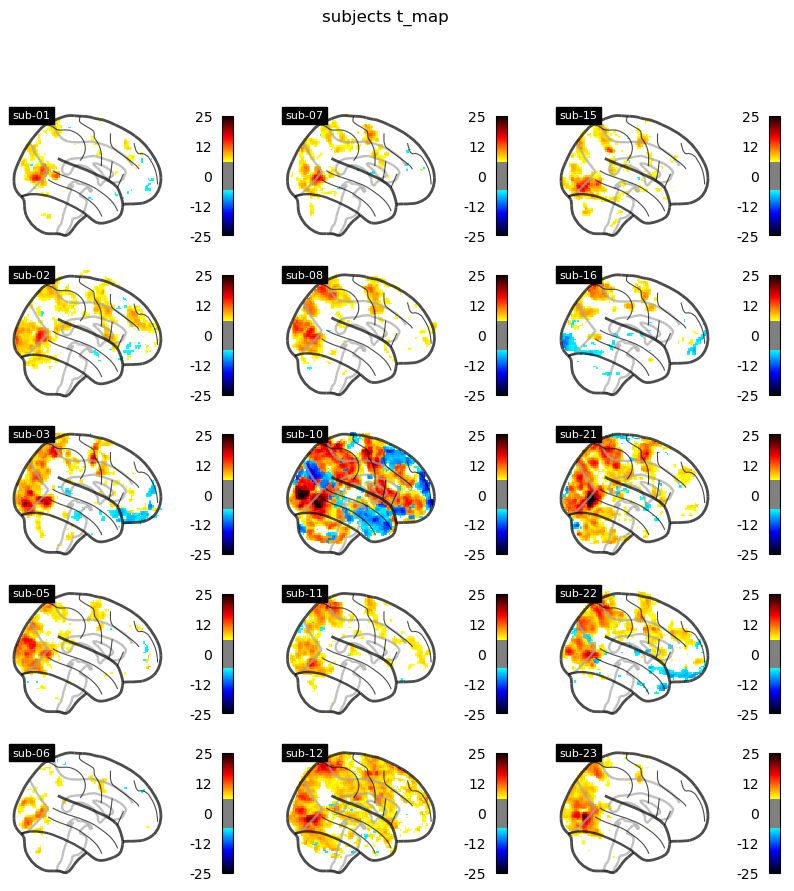

In [19]:
# Plot all subjects

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 10))
for cidx, tmap in enumerate(tmap_files):
    P = plotting.plot_glass_brain(
        tmap,
        colorbar=True,
        threshold=6.0,
        vmax=25,
        axes=axes[cidx % 5, int(cidx / 5)],
        plot_abs=False,
        display_mode="x",
    )
    P.title(subject_list[cidx], size=8)
fig.suptitle("subjects t_map")
plt.show()

In [20]:
# create design matrix for 2nd level
second_level_input = zmap_files
design_matrix_g = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

# define 2nd level model
second_level_model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=20)
second_level_model.minimize_memory = False
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix_g,
)

# compute contrast (z score map)
z_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
)

# compute contrast (beta map)
beta_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type='effect_size',
)

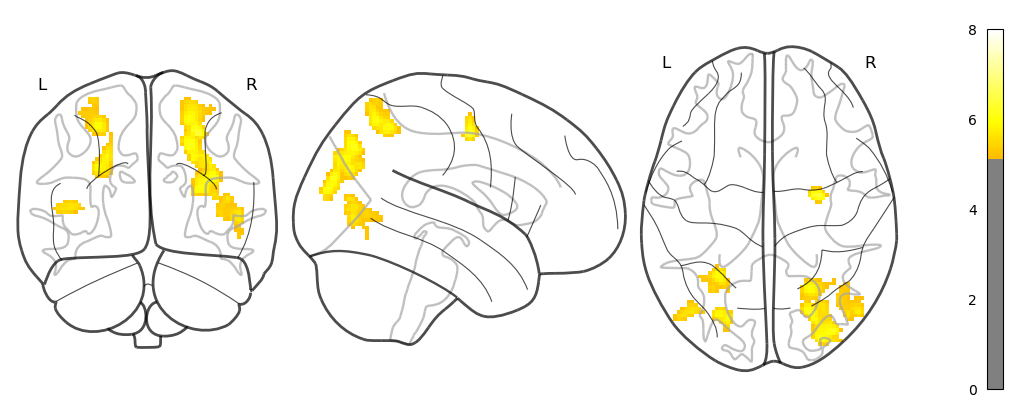

In [21]:
# Threshold zmap and plot it
clean_map_g, threshold_g = threshold_stats_img(
    z_map_g, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)

plotting.plot_glass_brain(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    plot_abs=False,
    display_mode="ortho",
    vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
)

plt.savefig(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                         f"group_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_plot.png"))

In [22]:
# Export cluster table
table,cluster_map_g = get_clusters_table(z_map_g, threshold_g, 50,
                                return_label_maps=True)

table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                          f"group_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_cluster-table.tsv"),sep='\t')
#print(table)
#print(table.to_latex())
table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,27.5,-8.5,49.5,6.369484,664
1,2,37.5,-84.5,23.5,6.187388,3984
2,2a,23.5,-74.5,41.5,6.127720,
3,2b,29.5,-88.5,17.5,6.107493,
4,2c,25.5,-78.5,33.5,5.971185,
5,3,23.5,-60.5,55.5,6.010417,1496
6,3a,35.5,-58.5,61.5,5.294902,
7,4,-26.5,-54.5,53.5,5.999720,1296
8,4a,-30.5,-60.5,67.5,5.463797,
9,5,-22.5,-78.5,35.5,5.928609,1256


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/matrix_plotting.py:366: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)


Extracting and saving residuals
Extracting and saving r_square


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)


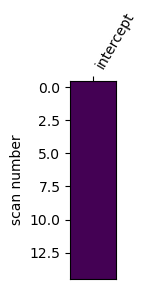

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


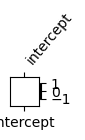

In [23]:
# Save group GLM
save_glm_to_bids(
    second_level_model,
    contrasts="intercept",
    contrast_types={"intercept": "t"},
    out_dir=os.path.join(data_dir,"derivatives","nilearn_glm","group"),
    prefix=f"group_task-{task_label}_acq-{acq_label}",
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



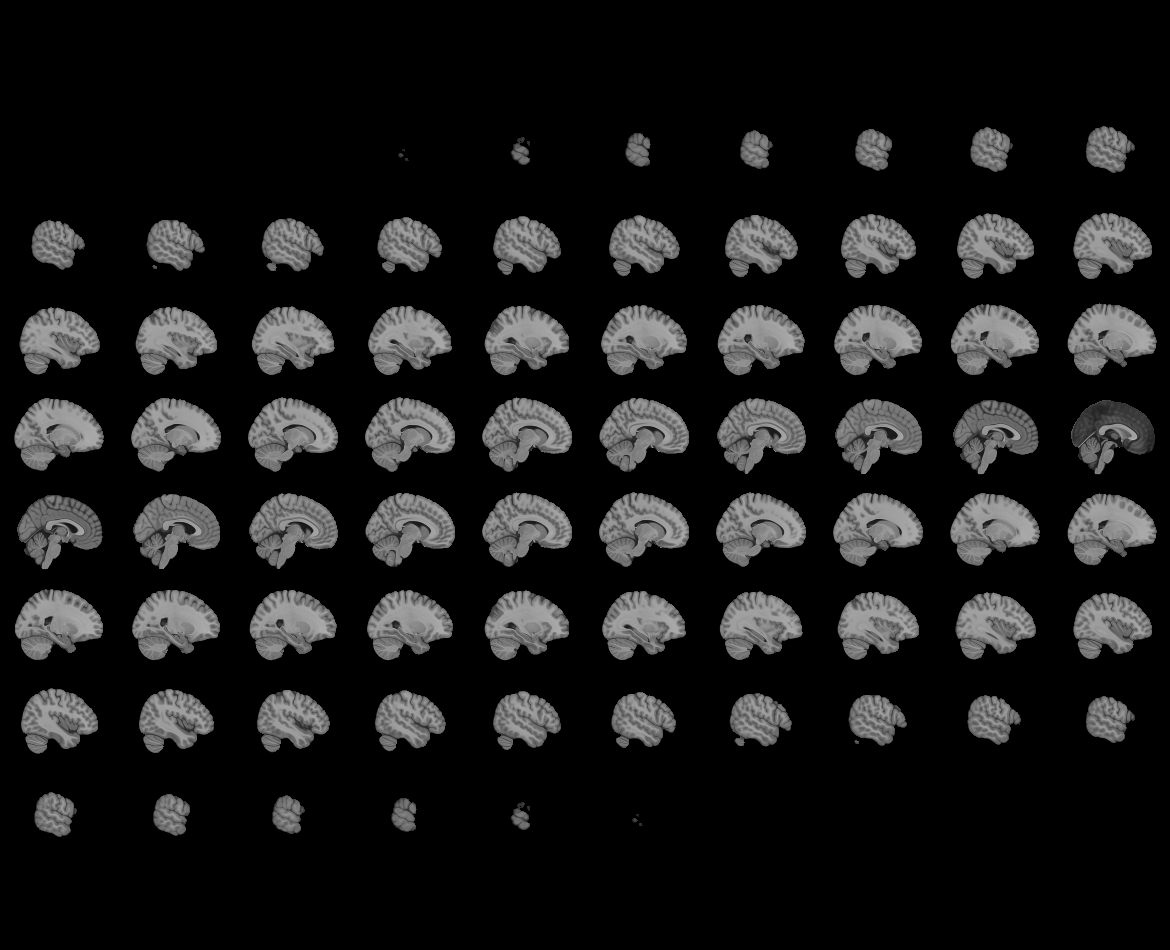
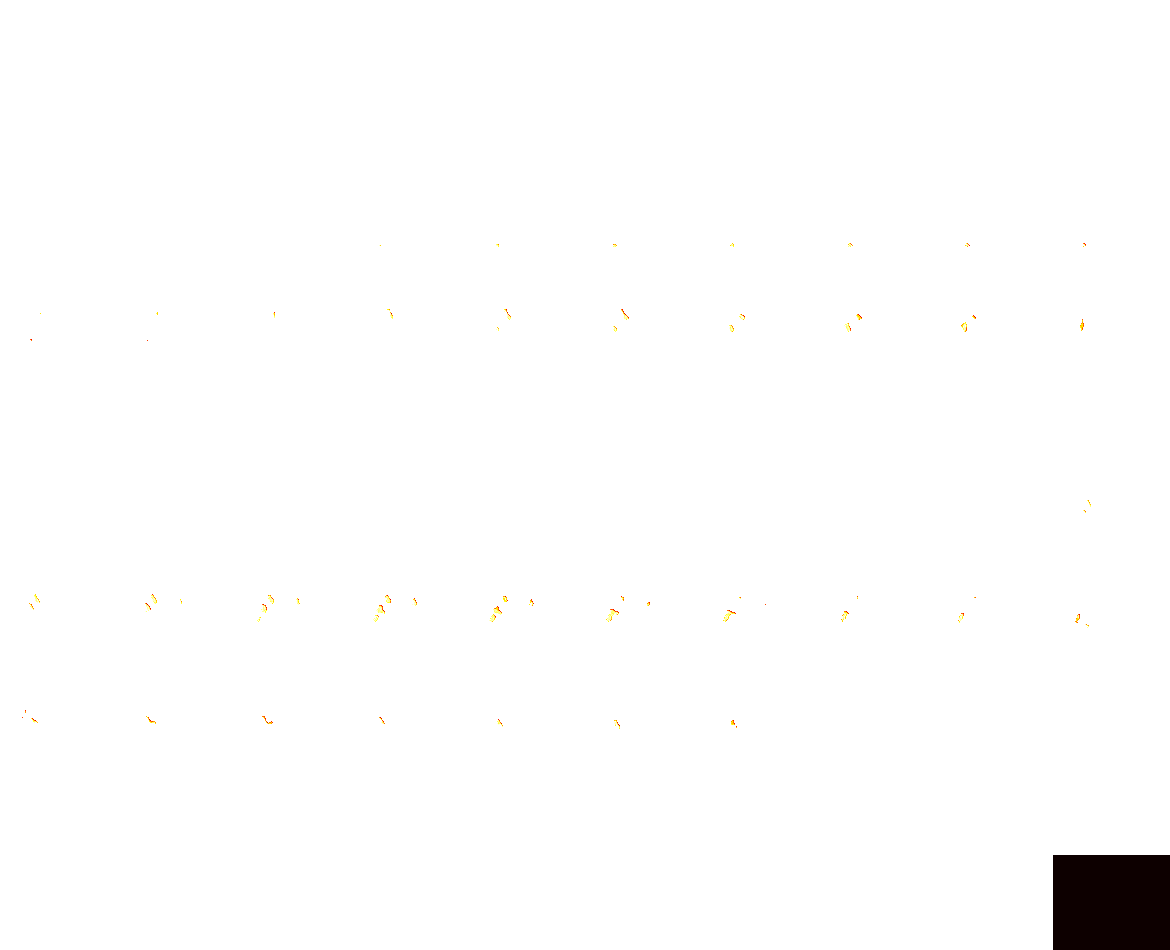

In [24]:
# View map interactively
plotting.view_img(clean_map_g,
         threshold=threshold_g
        )

# ROI analysis

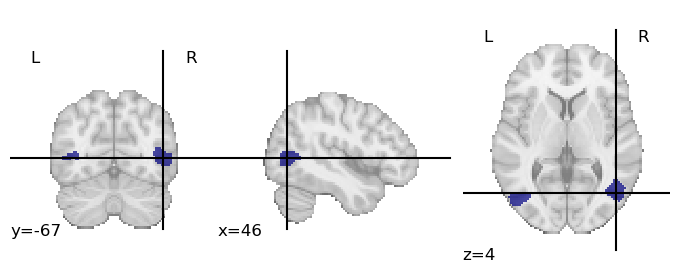

In [28]:
# Load mask from group GLM
mask_hMT = load_img(os.path.join(data_dir,"derivatives","nilearn_glm","group",'mask_hMT.nii.gz'))

plotting.plot_roi(mask_hMT)



In [29]:
# fetch map values inside mask_hMT  
# Apply mask to z_map_g
z_map_hMT = apply_mask(z_map_g, mask_hMT)

# Apply mask to beta_map_g
beta_map_hMT = apply_mask(beta_map_g, mask_hMT)

# Estimate mean of z_map_hMT
z_map_hMT_mean = np.mean(z_map_hMT)

z_map_hMT_mean

4.964519463135588